In [2]:
from pyfmreader.ps_nex.parseTDMS import get_channel_names, parse_tdms

In [3]:
file = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20.map/fcurve___2025.03.12_18.25.44.81.tdms'
# file = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20/fcurve___2025.03.12_18.23.29.39.tdms' #Fast approach  
# file = '/Users/evillz/Data/psnex_map___2024.10.15_16.31.06.47/fcurve___2024.10.15_16.36.20.28.tdms' # fast approach
# file = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/fcurve___2025.03.12_18.49.42.45.tdms'



In [4]:
# fast approach long range demonstration 
# file = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/fcurve___2025.03.12_18.47.16.88.tdms'

In [5]:
# Latest files 
# file = '/Users/evillz/Data/article/2025_12_06/1bead/psnex_map___2025.06.12_18.06.36.23/fcurve___2025.06.12_18.06.42.65.tdms'
file = '/Users/evillz/Data/article/2025_12_06/glass/fcurve_Glass_10um__2025.06.12_16.11.17.92.tdms'
file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.48.59.79.tdms'


In [6]:
# article
# file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_18.05.48.47.tdms'
# file = '/Users/evillz/Data/article/2025_30_5/fcurve___2025.05.30_18.17.35.76.tdms'

In [7]:
# # Slow approach example 
# file = '/Users/evillz/Data/article/2025_30_5/psnex_map__curves/fcurve___2025.05.30_18.14.38.08.tdms'

# file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_18.20.42.80/fcurve___2025.05.30_18.21.47.76.tdms'

# file = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/fcurve___2025.05.30_17.50.46.00.tdms'




In [8]:
from pyfmreader.plotting import load_fcurve_metadata, smooth_derivative


metadata, piezo_um, deflection_zero_N, time_s = load_fcurve_metadata(file)

All segments have decimation factors: 10, 10, 10


In [9]:
# time_s, piezo_um,
import numpy as np

piezo_deriv = np.gradient(piezo_um, time_s)  # Calculate the derivative of piezo_um with respect to time_s
deriv_piezo_smooth = smooth_derivative(piezo_um, time_s, window_size=100)

In [10]:
CheckMapfiles = False

if CheckMapfiles:
    import pyfmreader.ps_nex.loadpsnexMaps as maps
    map_path = '/Users/evillz/Data/article/2025_30_5'
    df_point_log = maps.checkMapFileNULL(map_path)

In [11]:


channels = get_channel_names(file)
for channel in channels:
    print(channel)
channel_data_deflection, channel_data_piezo, channel_time = parse_tdms(file, deflectionChannel=channels[0][0], zDisplacement=channels[0][1])

{0: 'Deflection_quotient_(V)', 1: 'Zpiezo_stage_sensor_(V)'}
Force Curve
2.0


In [12]:
from pyfmreader import loadfile
file_meta = loadfile(file)
metadata= file_meta.filemetadata
curve_index = 0


dec_app = int(metadata['curve_properties']['0'][0]['segment_0_dec_factor'])
dec_con = int(metadata['curve_properties']['0'][1]['segment_1_dec_factor'])
dec_ret = int(metadata['curve_properties']['0'][2]['segment_2_dec_factor'])
num_segment_arr = metadata['num_segments']


app_vel_v_tick = float(metadata['curve_properties']['0'][0]['segment_0_velocity(V/tick)'])
ret_vel_v_tick = float(metadata['curve_properties']['0'][2]['segment_2_velocity(V/tick)'])


if dec_app and dec_con and dec_ret:
    print(f'All segments have decimation factors: {dec_app}, {dec_con}, {dec_ret}')

#check if all decimation is the same
decimation_factor = metadata['curve_properties']['0'][0]['segment_0_dec_factor']
# metadata['curve_properties']['0'][0]


All segments have decimation factors: 10, 10, 10


In [13]:
from pyfmreader.ps_nex.parsepsnexheader import parsePSNEXheader


file_metadata = parsePSNEXheader(file)

fs = file_meta.filemetadata['curve_properties']['0'][0]['segment_0_sampling_rate_(S/s)']
tick_time_s = file_meta.filemetadata['curve_properties']['0'][0]['tick_time_s']
tick_time_z_loop = 2e-6 #500Khz
# metadata = file.metadata
# fs = 500e3
dt = 1/fs

relative_sr = (dt / decimation_factor) / tick_time_s
# get sensitivities for Z calibration
z_sens_um_v = float(file_meta.filemetadata['curve_properties']['0'][0]['z_stage_sensitivity'])/1e3
k = float(file_metadata['cantilever_spring_constant_calib_N/m']) # N/m
invols_m_v = float(file_metadata['invOLS_(nm/V)']) * 1e-9 # nm/V

#% calculate velocty 

# app_um_s = app_vel_v_tick * (0.025e-6 * 80) 
app_um_s = app_vel_v_tick / (tick_time_z_loop / decimation_factor) * (z_sens_um_v *1e-6)
print (f'app_vel = {app_um_s} m/s')
# ret_um_s = 

# convert channles to proper units
piezo_um = channel_data_piezo * z_sens_um_v
deflection_uN = channel_data_deflection * invols_m_v * k  # convert to um
deflection_zero_uN = deflection_uN - deflection_uN.mean() #subtract the mean to get center the curve on zero
time_s = channel_time * dt * decimation_factor *1e3  # convert to seconds

app_vel = 1.9997823e-05 m/s


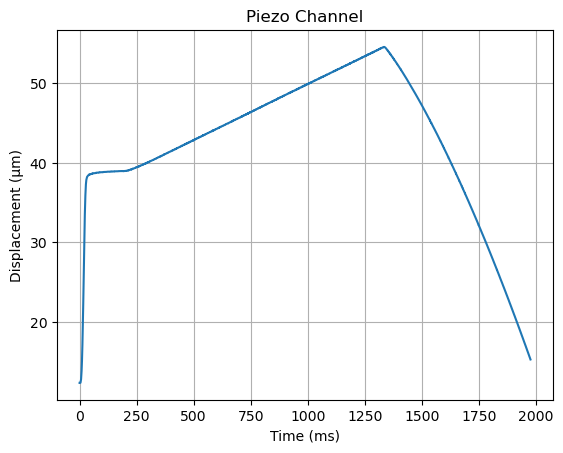

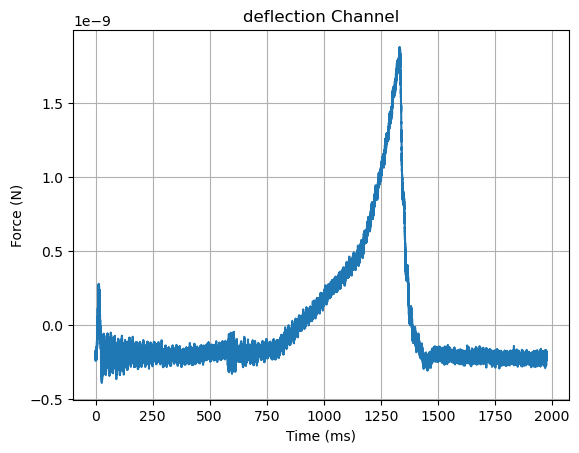

In [15]:
import matplotlib.pyplot as plt

# plot piezo channel vs time
plt.figure()
plt.plot(time_s, piezo_um, label='Piezo Channel (µm)')
plt.title('Piezo Channel')
plt.xlabel('Time (ms)')
plt.ylabel('Displacement (µm)')
plt.grid()
plt.show()

# plot piezo channel vs time
plt.figure()
plt.plot(time_s, deflection_zero_uN, label='Piezo Channel (µm)')
plt.title('deflection Channel')
plt.xlabel('Time (ms)')
plt.ylabel('Force (N)')
plt.grid()
plt.show()

In [16]:
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = 'plotly_dark'  # or try 'ggplot2', 'seaborn', etc.
print(pio.templates)

fig = go.Figure()

# Plot deflection vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=deflection_zero_uN,
    mode='lines',
    name='Deflection (µN)',
    yaxis='y1'  # Link to the first y-axis
))

# Plot piezo vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=piezo_um,
    mode='lines',
    name='Zstage Piezo (µm)',
    yaxis='y2'  # Link to the second y-axis
))

fig.update_layout(
    title='Fast approach force curve',
    xaxis=dict(
        title='Time (ms)',
        showgrid=True  # Remove x-axis grid
    ),
    yaxis=dict(
        title='Force (µN)',
        tickformat='.2f',
        side='right',
        showgrid=False  # Remove y-axis grid
    ),
    yaxis2=dict(
        title='Displacement (µm)',
        overlaying='y',
        side='left',
        showgrid=True  # Remove secondary y-axis grid
    ),
    legend=dict(x=0.01, y=0.99),
    width=1000,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',  # Transparent background
    plot_bgcolor='rgba(0,0,0,0)'    # Transparent plot area
)

fig.show()


Templates configuration
-----------------------
    Default template: 'plotly_dark'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']



In [17]:
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = 'plotly_dark'  # or try 'ggplot2', 'seaborn', etc.
print(pio.templates)

fig = go.Figure()

# Plot deflection vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=deflection_zero_uN,
    mode='lines',
    name='Deflection (µN)',
    yaxis='y1'  # Link to the first y-axis
))

# Plot piezo vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=piezo_um,
    mode='lines',
    name='Zstage Piezo (µm)',
    yaxis='y2'  # Link to the second y-axis
))

fig.update_layout(
    title='Fast approach force curve',
    xaxis=dict(
        title='Time (ms)',
        showgrid=True  # Remove x-axis grid
    ),
    yaxis=dict(
        title='Force (N)',
        tickformat='.2f',
        side='right',
        showgrid=False  # Remove y-axis grid
    ),
    yaxis2=dict(
        title='Displacement (µm)',
        overlaying='y',
        side='left',
        showgrid=True  # Remove secondary y-axis grid
    ),
    legend=dict(x=0.01, y=0.99),
    width=1000,
    height=600,
    paper_bgcolor='black',  # Black background
    plot_bgcolor='black'    # Black plot area
)

fig.show()


Templates configuration
-----------------------
    Default template: 'plotly_dark'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']



In [18]:
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = 'plotly_dark'  # or try 'ggplot2', 'seaborn', etc.
print(pio.templates)

fig = go.Figure()

# Plot deflection vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=deflection_zero_uN*1e9,
    mode='lines',
    name='Force (nN)',
    yaxis='y1'  # Link to the first y-axis
))

# Plot piezo vs time
fig.add_trace(go.Scatter(
    x=time_s,
    y=piezo_um,
    mode='lines',
    name='Zstage Piezo (µm)',
    yaxis='y2'  # Link to the second y-axis
))

fig.update_layout(
    legend=dict(
        x=0.01,
        y=0.99,
        font=dict(color='black', size=20)  # Set legend font color to black
    )
)

fig.update_layout(
    title=dict(
        text='Normal approach force curve',
        font=dict(color='black', size=24, family='Arial')  # Set title font properties
    ),
    xaxis=dict(
        title=dict(
            text='Time (ms)',
            font=dict(size=24, family='Arial')  # Set x-axis title font properties
        ),
        showgrid=True,  # Remove x-axis grid
        color='black',  # Set x-axis text color to black
        tickfont=dict(size=18)  # Set x-axis tick font size
    ),
    yaxis=dict(
        title=dict(
            text='Force (nN)',
            font=dict(size=24, family='Arial')  # Set y-axis title font properties
        ),
        tickformat='.2f',
        side='right',
        showgrid=False,  # Remove y-axis grid
        color='black',  # Set y-axis text color to black
        tickfont=dict(size=18)  # Set y-axis tick font size
    ),
    yaxis2=dict(
        title=dict(
            text='Displacement (µm)',
            font=dict(size=24, family='Arial')  # Set secondary y-axis title font properties
        ),
        overlaying='y',
        side='left',
        showgrid=True,  # Remove secondary y-axis grid
        color='black',  # Set secondary y-axis text color to black
        tickfont=dict(size=18)  # Set secondary y-axis tick font size
    ),
    legend=dict(x=0.01, y=0.99),
    width=1000,
    height=600,
    paper_bgcolor='rgba(0,0,0,0)',  # Transparent background
    plot_bgcolor='rgba(0,0,0,0)'    # Transparent plot area
)

fig.show()


Templates configuration
-----------------------
    Default template: 'plotly_dark'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']



In [19]:
# # time_s, piezo_um,
# import numpy as np

# piezo_deriv = np.gradient(piezo_um, time_s)  # Calculate the derivative of piezo_um with respect to time_s
# deriv_piezo_smooth = smooth_derivative(piezo_um, time_s, window_size=100)

In [20]:
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = 'plotly_dark'  # or try 'ggplot2', 'seaborn', etc.
print(pio.templates)


colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

color2_z_velocity = colors[0]
color1_piezo_displacement = colors[1] 
def_color = colors[2]

# color2_z_velocity = 'blue'
# color1_piezo_displacement = 'red'
# def_color = 'green'



font = 'Helvetica'
xfontSize = 24
yfontSize = 24

fig = go.Figure()

# Plot Piezo vs time
fig.add_trace(go.Scatter(
    x=time_s[::100],
    y=piezo_um[::100],
    mode='lines',
    name='Z piezo(µm)',
    yaxis='y1',  # Link to the first y-axis
    line=dict(color=color1_piezo_displacement, width=2)  # Change color and width of the line
))


# Plot piezo derive  vs time
fig.add_trace(go.Scatter(
    x=time_s[::100],
    y=deriv_piezo_smooth[::100]*1e-3,
    mode='lines',
    name='Z vel(mm/s)',
    yaxis='y2',  # Link to the second y-axis
    line=dict(color=color2_z_velocity, width=2)  # Change color and width of the line
))

# Plot piezo vs time
fig.add_trace(go.Scatter(
    x=time_s[::100],
    y=deflection_zero_uN[::100],
    mode='lines',
    name='Force (µN)',
    yaxis='y3',  # Link to the second y-axis
    line=dict(color=def_color, width=2)  # Change color and width of the line
))

fig.update_layout(
    title='Z piezo fast approach force curve',
    title_font=dict(size=24, color='black'), 
    showlegend=False,   # Set title font properties
    # xaxis=dict(
    #     title='Time (ms)',
    #     showgrid=True,  # Remove x-axis grid
    #     color = 'black'
    # ),

    xaxis=dict(
        title=dict(
            text='Time (ms)',
            font=dict(size=xfontSize, family=font)  # Set x-axis title font properties
        ),
        showgrid=True,  # Remove x-axis grid
        color='black',  # Set x-axis text color to black
        tickfont=dict(size=24)  # Set x-axis tick font size
        ),
    # legend=dict(
    #     x=0.5,         # horizontal position (0 = far left, 1 = far right)
    #     y=1.1,         # vertical position (0 = bottom, 1 = top)
    #     xanchor="center",  # anchor relative to x (options: "left", "center", "right")
    #     yanchor="bottom",  # anchor relative to y (options: "top", "middle", "bottom")
    #     orientation="h",   # "h" for horizontal, "v" for vertical
    #     bgcolor="rgba(255,255,255,0.5)",  # optional: semi-transparent white background
    #     bordercolor="black",
    #     borderwidth=1
    # ),
    yaxis=dict(
        title='piezo(µm)',
        tickformat='1.f',
        side='right',
        showgrid=False,  # Remove y-axis grid
        color=color1_piezo_displacement,  # Change color 
        # change font size 
        tickfont= dict(size=24, family = font)  # Set y-axis tick font size
        
    ),
    yaxis2=dict(
        title='Vel(mm/s)',
        overlaying='y',
        side='left',
        showgrid=True,  # Remove secondary y-axis grid
        color=color2_z_velocity, # Change color and width of the line
        position= 0.0,
        tickfont= dict(size=24)  # Set y-axis tick font size

    ),
    yaxis3=dict(
        title='Force(N)',
        overlaying='y',
        side='left',
        showgrid=False,  # Remove secondary y-axis grid
        color=def_color, # Change color and width of the line
        position= 0.4,
        tickfont= dict(size=24)  # Set y-axis tick font size

    ),
    legend=dict(
        x=0.99, y=0.99,
        font= dict(color='black', size=24),  # Set legend font color to black
        # hide legend
        
        
        
        ),
    width=1000,
    height=600,
    # paper_bgcolor='black',  # Black background
    # plot_bgcolor='black'    # Black plot area
    paper_bgcolor='rgba(0,0,0,0)',  # Transparent background
    plot_bgcolor='rgba(0,0,0,0)'    # Transparent plot area
)
alignment = 'right'
x_legend = 0.99
fig.add_annotation(
    xref='paper', yref='paper',
    x=x_legend, y=0.98,
    showarrow=False,
    text="<b><span style='color:#2ca02c''>Z displacement (µm)</span></b>",
    font=dict(size=14),
    align=alignment,
)

fig.add_annotation(
    xref='paper', yref='paper',
    x=x_legend, y=0.94,
    showarrow=False,
    text="<b><span style='color:#1f77b4'>Z velocity (mm/s)</span></b>",
    font=dict(size=14),
    align=alignment,
)

fig.add_annotation(
    xref='paper', yref='paper',
    x=x_legend, y=0.90,
    showarrow=False,
    text="<b><span style='color:#ff7f0e'>Deflection (nN)</span></b>",
    font=dict(size=14),
    align=alignment,
)

fig.show()


Templates configuration
-----------------------
    Default template: 'plotly_dark'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']



In [21]:
fig.update_layout(
    xaxis=dict(
        title=dict(
            text='Time (ms)',
            font=dict(size=xfontSize, family=font)
        ),
        showgrid=False,
        color='black',
        tickfont=dict(size=24)
    ),
    yaxis=dict(
        title='piezo(µm)',
        tickformat='1.f',
        side='right',
        showgrid=False,
        color=color1_piezo_displacement,
        tickfont=dict(size=24, family=font)
    ),
    yaxis2=dict(
        title='Velocity(mm/s)',
        overlaying='y',
        side='right',  # Changed to 'right' to put ticks on the right
        showgrid=False,
        color=color2_z_velocity,
        position=0.0,
        tickfont=dict(size=24),
        title_standoff=25  # Push title to the left
    ),
    yaxis3=dict(
        title='Force(N)',
        overlaying='y',
        side='right',  # Changed to 'right' to put ticks on the right
        showgrid=False,
        color=def_color,
        position=0.08,
        tickfont=dict(size=24),
        title_standoff=25  # Push title to the left
    ),
)


In [22]:
saveSVG = False
if saveSVG :
    dir_path = '/Users/evillz/Data/article'
    filename = 'diagram_1'+ os.path.split(file)[-1][:-5] + 'fcurve.svg'
    img_path = os.path.join(dir_path, filename)
    print (img_path)
    fig.write_image(img_path)

In [23]:
# get figure zoom settings
x_range = [0, 500]  # Set time axis zoom from 0 to 500 ms
y1_range = fig.layout.yaxis.range if fig.layout.yaxis.range else [piezo_um.min(), piezo_um.max()]
y2_range = fig.layout.yaxis2.range if fig.layout.yaxis2.range else [deriv_piezo_smooth.min()*1e-3, deriv_piezo_smooth.max()*1e-3]
y3_range = fig.layout.yaxis3.range if fig.layout.yaxis3.range else [deflection_zero_uN.min(), deflection_zero_uN.max()]

# print ranges of each y axis
print(f'x_range: {x_range}')
print(f'y1_range (piezo): {y1_range}')
print(f'y2_range (velocity): {y2_range}')   
print(f'y3_range (force): {y3_range}')


x_range: [0, 500]
y1_range (piezo): [np.float64(12.362591743469238), np.float64(54.54799032211304)]
y2_range (velocity): [np.float64(-0.08297573845334502), np.float64(1.67641925811768)]
y3_range (force): [np.float64(-3.8899033822115025e-10), np.float64(1.881661898717327e-09)]


In [24]:
# apply zoom settings to saved svg file
fig.update_layout(
    xaxis=dict(range=x_range),
    yaxis=dict(range=y1_range),
    yaxis2=dict(range=y2_range),
    yaxis3=dict(range=y3_range)
)       



In [25]:
import os
saveSVG = False
if saveSVG :
    dir_path = '/Users/evillz/Data/article'
    filename = 'diagram_1'+ os.path.split(file)[-1][:-5] + 'fcurve_zoom.svg'
    img_path = os.path.join(dir_path, filename)
    print (img_path)
    fig.write_image(img_path)

 

In [26]:
# create html file to load in browser
import plotly.io as pio

dir_path = '/Users/evillz/Library/CloudStorage/OneDrive-Aix-MarseilleUniversité/PHD2024/CSI/CSI_2'
html_filename = 'force_curve.html'
filename =  os.path.join(dir_path, html_filename)
print (f'filepath: {filename}')
print(os.path.exists(filename))
# pio.write_html(fig, file=html_filename, auto_open=True)

filepath: /Users/evillz/Library/CloudStorage/OneDrive-Aix-MarseilleUniversité/PHD2024/CSI/CSI_2/force_curve.html
True
